In [ ]:
import pandas as pd

# ── 1. ASSUMPTIONS ────────────────────────────────────────────────────────────
AIR_DENSITY       = 1.27      # kg/m³
SPECIFIC_HEAT     = 1.007     # kJ/kg/K
LPHW_EFFICIENCY   = 0.85      # boiler/LPHW efficiency
CHW_COP           = 4.0       # chiller COP
GAS_COST          = 0.06      # £/kWh
ELEC_COST         = 0.20      # £/kWh

# ── 2. EQUIPMENT ──────────────────────────────────────────────────────────────
equipment = [
    {"name": "AHU - Sample", "air_flow_m3s": 20, "temp_setpoint": 15, "hours_per_year": 4368},
    # Add more AHUs here if needed:
    # {"name": "AHU - Office", "air_flow_m3s": 10, "temp_setpoint": 18, "hours_per_year": 2500},
]

# ── 3. LOAD WEATHER DATA ──────────────────────────────────────────────────────
WEATHER_FILE = "Air - Heating&Cooling Calc Spreadsheet.xlsx"

weather_df = pd.read_excel(WEATHER_FILE, sheet_name="3.Site Weather Data PEAK", header=1)
weather_df.columns = ["row", "timestamp", "outdoor_temp_c", "sample"]
weather_df = weather_df[["timestamp", "outdoor_temp_c"]].dropna()

weather_df["datetime"] = pd.to_datetime(weather_df["timestamp"])
weather_df["month"] = weather_df["datetime"].dt.strftime("%b")

# Filter weather data for operating hours (7 AM to 7 PM)
weather_df["hour"] = weather_df["datetime"].dt.hour
weather_df = weather_df[(weather_df["hour"] >= 7) & (weather_df["hour"] < 19)] # 7 AM to 6:59 PM

# ── 4. CALCULATION ────────────────────────────────────────────────────────────
def calc_energy(row, air_flow, temp_setpoint, yearly_run_fraction):
    """Calculate heating and cooling kW for a single timestep."""
    delta_t = temp_setpoint - row["outdoor_temp_c"]

    thermal_kw = air_flow * AIR_DENSITY * SPECIFIC_HEAT * abs(delta_t)

    if delta_t > 0:   # outdoor is colder → need heating
        heating_kw = thermal_kw / LPHW_EFFICIENCY
        cooling_kw = 0
    else:              # outdoor is warmer → need cooling
        heating_kw = 0
        cooling_kw = 0 # Cooling demand is met locally, set to 0

    # Scale by how much of the year the unit actually runs
    heating_kw *= yearly_run_fraction
    cooling_kw *= yearly_run_fraction

    return heating_kw, cooling_kw


# ── 5. RUN FOR EACH PIECE OF EQUIPMENT ────────────────────────────────────────
HOURS_IN_YEAR = 8760
INTERVAL_HRS  = 0.5   # half-hourly data

print("=" * 60)
print("  HVAC ENERGY COST SUMMARY")
print("=" * 60)

for unit in equipment:
    run_fraction = unit["hours_per_year"] / HOURS_IN_YEAR

    results = weather_df.apply(
        calc_energy,
        axis=1,
        air_flow=unit["air_flow_m3s"],
        temp_setpoint=unit["temp_setpoint"],
        yearly_run_fraction=run_fraction,
        result_type="expand"
    )
    results.columns = ["heating_kw", "cooling_kw"]

    # Convert kW readings to kWh (each row = 0.5 hr interval)
    results["heating_kwh"] = results["heating_kw"] * INTERVAL_HRS
    results["cooling_kwh"] = results["cooling_kw"] * INTERVAL_HRS

    total_heating_kwh = results["heating_kwh"].sum()
    total_cooling_kwh = results["cooling_kwh"].sum()
    total_cost        = (total_heating_kwh * GAS_COST) + (total_cooling_kwh * ELEC_COST)

    print(f"\nEquipment : {unit['name']}")
    print(f"Air Flow  : {unit['air_flow_m3s']} m³/s  |  Setpoint: {unit['temp_setpoint']}°C  |  Hours/Year: {unit['hours_per_year']}")
    print("-" * 60)

    # Monthly breakdown
    weather_df_copy = weather_df.copy()
    weather_df_copy["heating_kwh"] = results["heating_kwh"].values
    weather_df_copy["cooling_kwh"] = results["cooling_kwh"].values

    month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    monthly = weather_df_copy.groupby("month")[["heating_kwh","cooling_kwh"]].sum()
    monthly = monthly.reindex(month_order).fillna(0)

    print(f"{'Month':<6} {'Heating kWh':>13} {'Cooling kWh':>13}  {'Gas Cost £':>10}  {'Elec Cost £':>11}")
    print("-" * 60)
    for month, row in monthly.iterrows():
        gas_cost  = row["heating_kwh"] * GAS_COST
        elec_cost = row["cooling_kwh"] * ELEC_COST
        print(f"{month:<6} {row['heating_kwh']:>13,.0f} {row['cooling_kwh']:>13,.0f}  {gas_cost:>10,.2f}  {elec_cost:>11,.2f}")

    print("-" * 60)
    print(f"{'TOTAL':<6} {total_heating_kwh:>13,.0f} {total_cooling_kwh:>13,.0f}  {total_heating_kwh*GAS_COST:>10,.2f}  {total_cooling_kwh*ELEC_COST:>11,.2f}")
    print(f"\n  ♣ Total Annual Energy Cost: £{total_cost:,.2f}")

print("\n" + "=" * 60)


FileNotFoundError: [Errno 2] No such file or directory: 'Air - Heating&Cooling Calc Spreadsheet.xlsx'

In [ ]:
display(weather_df)

,timestamp,outdoor_temp_c,datetime,month,hour
27,2021-01-01 07:00:00,2.42,2021-01-01 07:00:00,Jan,7
28,2021-01-01 07:15:00,2.39,2021-01-01 07:15:00,Jan,7
29,2021-01-01 07:30:00,2.07,2021-01-01 07:30:00,Jan,7
30,2021-01-01 07:45:00,2.03,2021-01-01 07:45:00,Jan,7
31,2021-01-01 08:00:00,2.02,2021-01-01 08:00:00,Jan,8
...,...,...,...,...,...
35019,2021-12-31 18:00:00,11.94,2021-12-31 18:00:00,Dec,18
35020,2021-12-31 18:15:00,11.88,2021-12-31 18:15:00,Dec,18
35021,2021-12-31 18:30:00,11.84,2021-12-31 18:30:00,Dec,18
35022,2021-12-31 18:45:00,11.81,2021-12-31 18:45:00,Dec,18


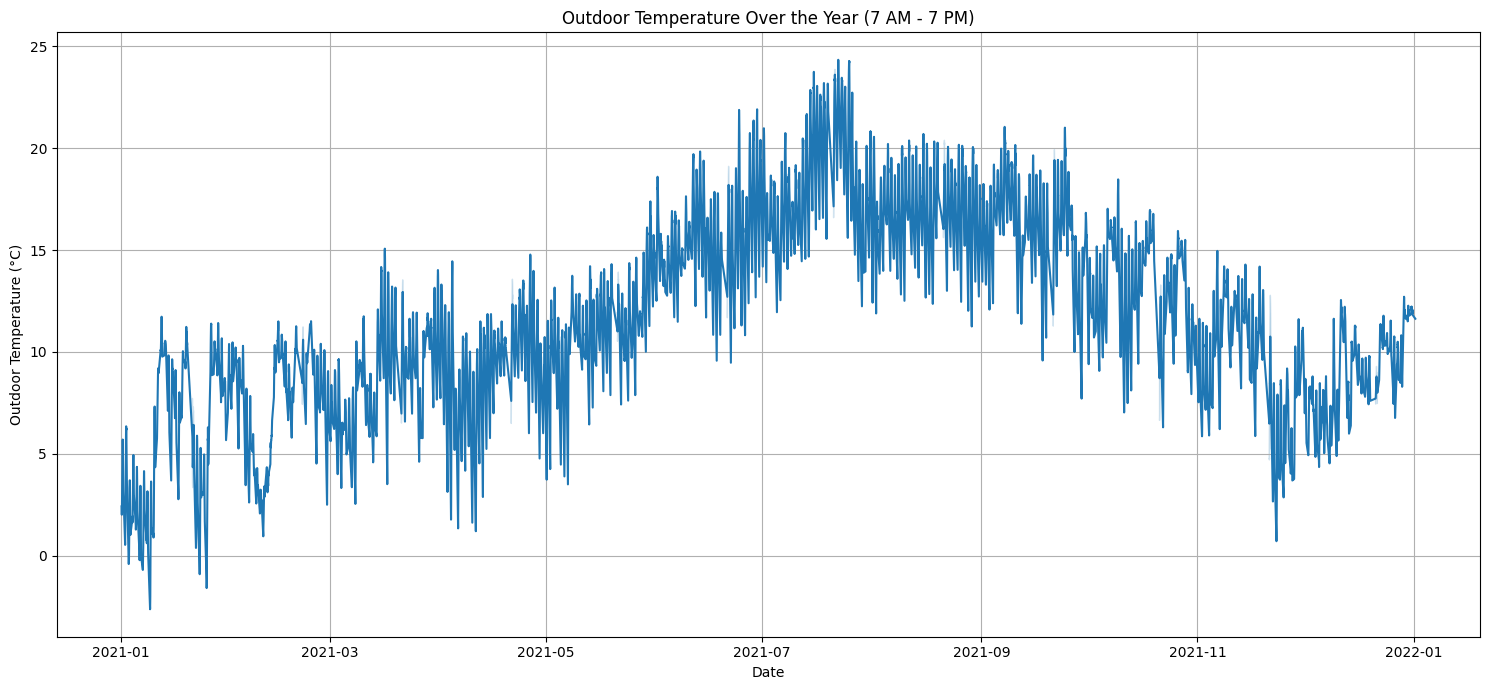

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(x='datetime', y='outdoor_temp_c', data=weather_df)
plt.title('Outdoor Temperature Over the Year (7 AM - 7 PM)')
plt.xlabel('Date')
plt.ylabel('Outdoor Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()